## Goal is to use NLP and machine learning to predict target countries of cyber attacks

Aim: Can the latent topics emerging from the incident descriptions a) predict countries targeted by cyber attacks and b) societal impact above and beyond the incident types already present in the data set (data theft, disruption, hijacking, physical effects (spatial), physical effects (temporal))?

### Hypotheses
H1: Target Countries
Existing categories are broad. BERTopic themes may capture more nuanced operational intent and therefore better predict who gets targeted. BERTopics will outperform existing categories in predicting target countries. 

H2: Impact
BERTopics are more fine-grained than the existing cyber operation categories and may explain additional variance in impact scores. 

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import shap

In [18]:
# load dyadic data
dyadic_data_topic = pd.read_csv(
    "data/eurepoc_dataset/dyadic_data_topics.csv"
)

# original dyadic data
url = "https://zenodo.org/records/14965395/files/eurepoc_dyadic_dataset_0_1.csv?download=1"

dyadic_data_orig = pd.read_csv(url)

In [19]:
# The topic analysis removed topic outliers (assigned -1) and short word descriptions (n < 5)
# Filter dyadic_data_orig so they're the same in order to compare models 
common_ids = set(
    dyadic_data_topic["incident_id"]
)

dyadic_data_orig_matched = dyadic_data_orig[
    dyadic_data_orig["incident_id"].isin(common_ids)
].copy()

print(dyadic_data_topic.shape)
print(dyadic_data_orig_matched.shape)

(2246, 52)
(2246, 57)


# Predicting Target Country
## Model A: Existing operation categories only

In [20]:
# First, drop countries that only appear a few times in the dataset 
# as they will be very difficult to predict
before = dyadic_data_orig_matched["receiver_country"].nunique()

filtered_orig = dyadic_data_orig_matched.groupby("receiver_country").filter(
    lambda x: len(x) >= 50
)

after = filtered_orig["receiver_country"].nunique()

print(f"Removed {before - after} countries with fewer than 50 observations")

Removed 169 countries with fewer than 50 observations


In [21]:
# Model A: Existing features only 
existing_features = [
    "Data theft",
    "Data theft & Doxing",
    "Hijacking with Misuse",
    "Hijacking without Misuse",
    "Ransomware"
]

control_features = [
    "initiator_country",
    "cyber_conflict_issue",
    "offline_conflict_intensity",
    "functional_impact",
    "intelligence_impact",
    "economic_impact",
    "affected_entities_value",
    "affected_third_countries_value"
]
 # One-hot encode categorical variables
X_controls = pd.get_dummies(
    filtered_orig[control_features],
    drop_first=True
)

X_existing = pd.concat(
    [
        X_controls,
        filtered_orig[existing_features]
    ],
    axis=1
)

# Fix columns with special characters
X_existing.columns = (
    X_existing.columns
    .astype(str)
    .str.replace(r"[^A-Za-z0-9_]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

# encode y labels to integers
le = LabelEncoder()
y = le.fit_transform(filtered_orig["receiver_country"])

In [22]:
# Split into training and testing data
X_train_A , X_test_A, y_train_A, y_test_A = train_test_split(
    X_existing,
    y,
    test_size=0.2,
    random_state = 99,
    stratify=y
)

print(X_train_A.shape)
print(X_test_A.shape)
print(y_train_A.shape)
print(y_test_A.shape)

(659, 73)
(165, 73)
(659,)
(165,)


In [23]:
# Define model A
xgbA = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=99
)

# 5-fold stratified CV
cv = StratifiedKFold(
    n_splits = 5,
    shuffle=True,
    random_state=99
)

# Cross-validation on training data
cv_scores_A = cross_val_score(
    xgbA,
    X_train_A,
    y_train_A,
    cv=cv,
    scoring="balanced_accuracy"
)

print("CV Scores:", cv_scores_A)
print("Mean CV Score:", np.mean(cv_scores_A))
print("Std Dev:", np.std(cv_scores_A))

CV Scores: [0.43223443 0.50950716 0.45732601 0.42204462 0.3977689 ]
Mean CV Score: 0.4437762237762238
Std Dev: 0.03801658074701061


In [24]:
# Fit on the full training set and evaluate on the holdout test set
xgbA.fit(X_train_A, y_train_A)

y_pred_A = xgbA.predict(X_test_A)
pred_labels_A = le.inverse_transform(y_pred_A)
true_labels_A = le.inverse_transform(y_test_A)

print(
    "Test Balanced Accuracy:",
    balanced_accuracy_score(true_labels_A, pred_labels_A)
)

print(classification_report(true_labels_A, pred_labels_A))

Test Balanced Accuracy: 0.41581099676337774
                precision    recall  f1-score   support

        France       0.19      0.20      0.19        15
       Germany       0.40      0.40      0.40        15
         India       0.50      0.23      0.32        13
        Russia       0.86      0.43      0.57        14
       Ukraine       0.58      0.54      0.56        13
United Kingdom       0.36      0.29      0.32        14
 United States       0.68      0.83      0.75        81

      accuracy                           0.58       165
     macro avg       0.51      0.42      0.44       165
  weighted avg       0.58      0.58      0.57       165



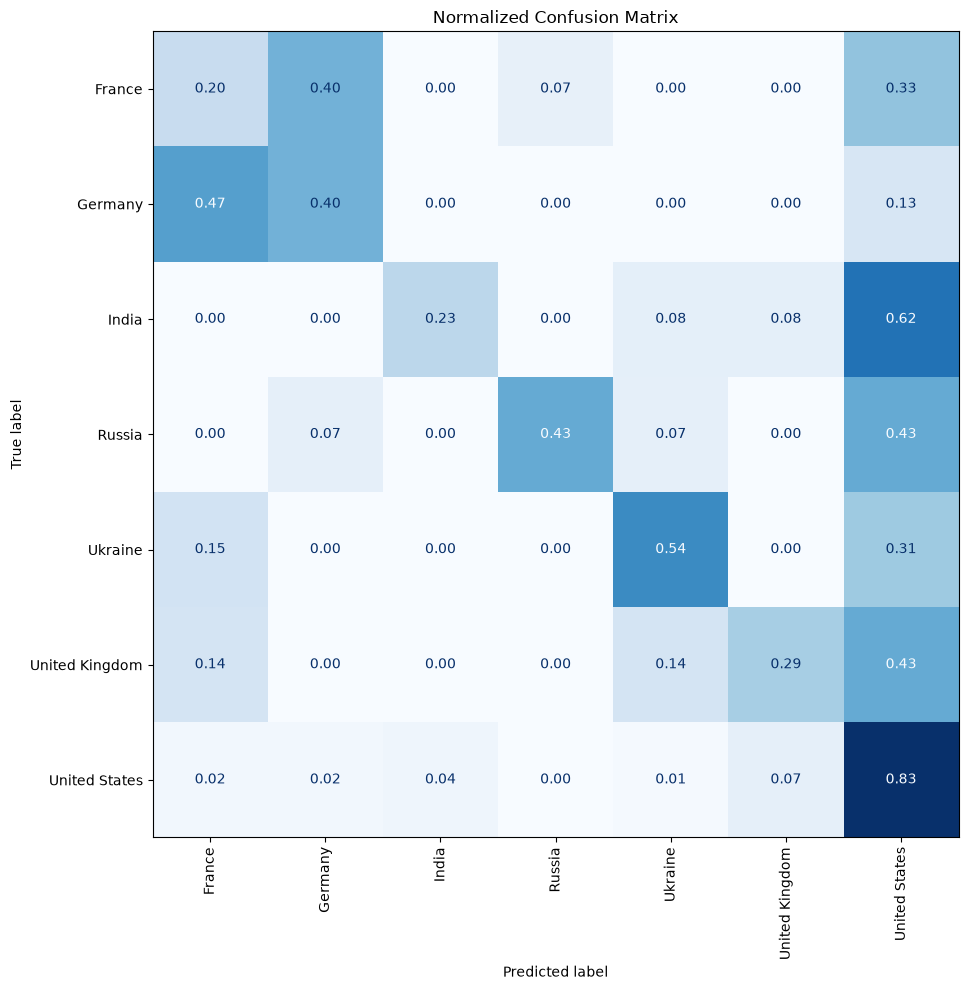

In [25]:
# Confusion matrix
cm = confusion_matrix(
    true_labels_A,
    pred_labels_A,
    labels=le.classes_
)

# Plot
cm_norm = confusion_matrix(
    true_labels_A,
    pred_labels_A,
    labels=le.classes_,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    ax=ax,
    colorbar=False,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

(165, 73, 7)
                                              feature  importance
1                      affected_third_countries_value    0.913626
0                             affected_entities_value    0.348880
52                       cyber_conflict_issue_Unknown    0.319116
53                 offline_conflict_intensity_Unknown    0.272396
58                    functional_impact_Not_available    0.270056
24                   initiator_country_Not_attributed    0.212803
29                           initiator_country_Russia    0.194971
54      offline_conflict_intensity_Yes_HIIK_intensity    0.189505
41                          initiator_country_Unknown    0.182672
68                                         Data_theft    0.165987
70                              Hijacking_with_Misuse    0.158049
44           cyber_conflict_issue_International_power    0.156443
64                  intelligence_impact_Not_available    0.152768
8                             initiator_country_China    0.1518

/Users/heather.iriye/Library/CloudStorage/OneDrive-KarolinskaInstitutet/Documents/GitHub/eurepoc_cyber_security-/venv/lib/python3.14/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


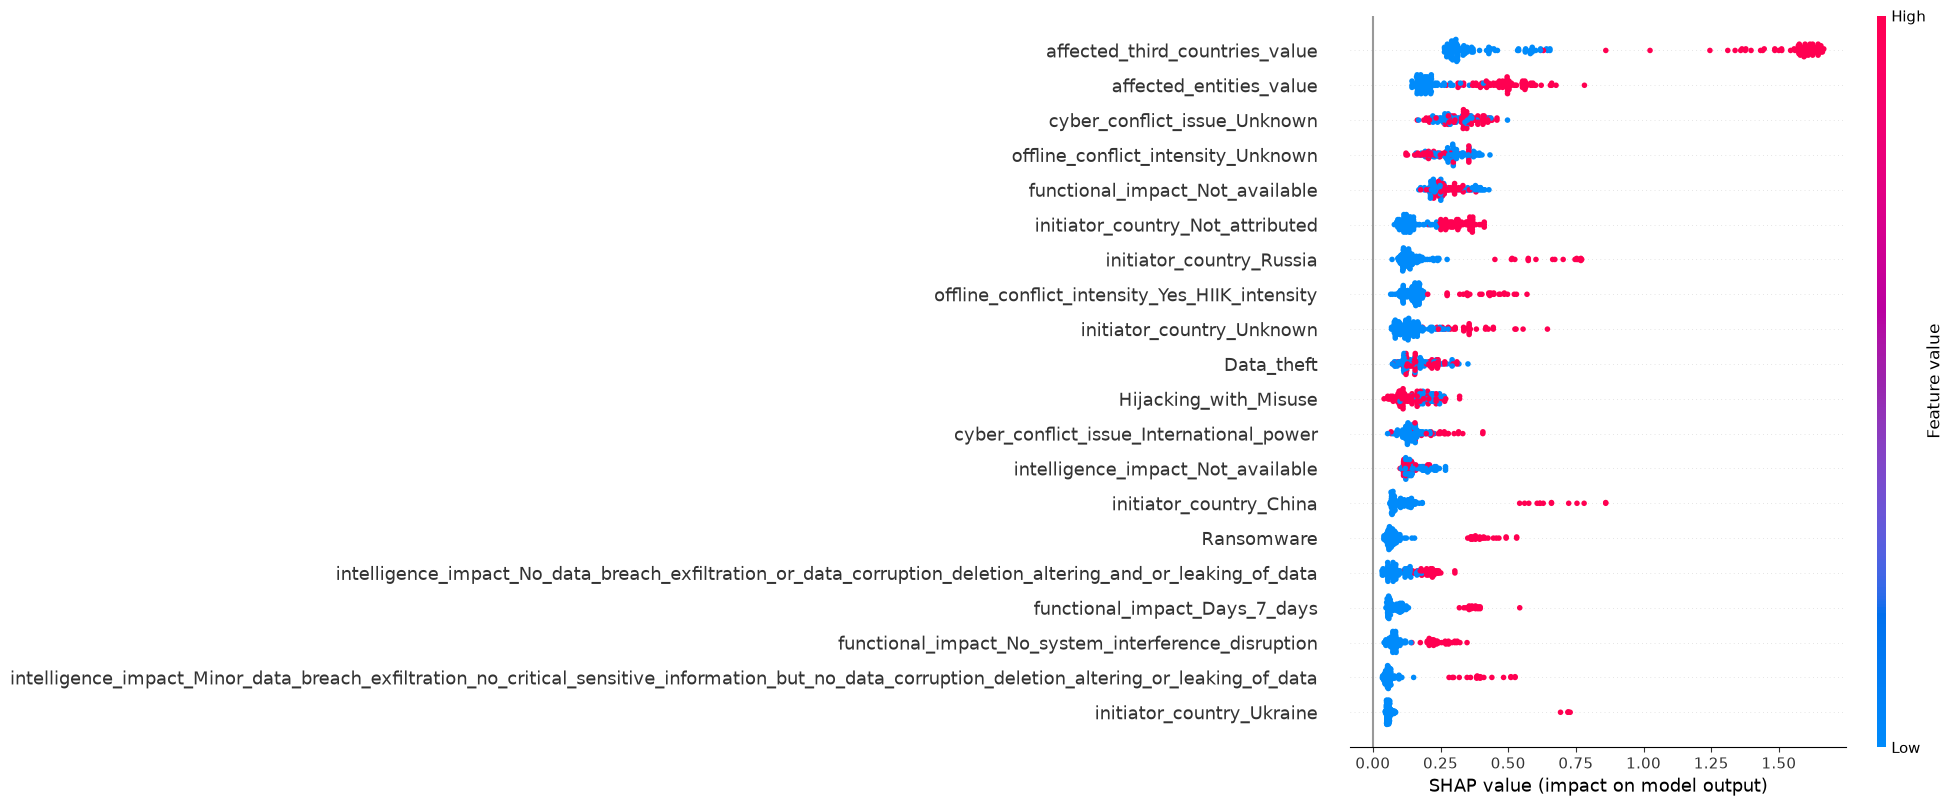

In [26]:
# Assess feature importance
explainer = shap.TreeExplainer(xgbA)
shap_values = explainer.shap_values(X_test_A)
print(shap_values.shape)

mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

shap_importance = pd.DataFrame({
    "feature": X_test_A.columns,
    "importance": mean_abs_shap
}).sort_values(
    "importance",
    ascending=False
)

print(shap_importance.head(20))

shap.summary_plot(
    np.abs(shap_values).mean(axis=2),
    X_test_A
)

## Model A Summary: Pre-Existing Cyber Operation Topics
Using traditional operational categories and control variables, the model achieved a balanced accuracy of 0.43 when predicting target countries. Predictive performance varied substantially across countries, suggesting that existing cyber-operation classifications capture some targeting patterns but provide limited discrimination between several countries.

# Model B: Latent Cyber Operation Topics

In [27]:
# First, drop countries that only appear a few times in the dataset 
# as they will be very difficult to predict
before = dyadic_data_topic["receiver_country"].nunique()

filtered_topic = dyadic_data_topic.groupby("receiver_country").filter(
    lambda x: len(x) >= 50
)

after = filtered_topic["receiver_country"].nunique()

print(f"Removed {before - after} countries with fewer than 50 observations")


Removed 169 countries with fewer than 50 observations


In [28]:
# One-hot encode control variables
X_controls = pd.get_dummies(
    filtered_topic[control_features],
    drop_first=True
)

# One-hot encode BERTopic assignments
X_topics = pd.get_dummies(
    filtered_topic["topic"],
    prefix="topic",
    drop_first=True
)

# Combine controls and topics
X_topic = pd.concat(
    [X_controls, X_topics],
    axis=1
)

# Clean column names for XGBoost
X_topic.columns = (
    X_topic.columns
    .astype(str)
    .str.replace(r"[^A-Za-z0-9_]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

# Encode y labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(
    filtered_topic["receiver_country"]
)

In [29]:
# Split into training and testing data
X_train_B , X_test_B, y_train_B, y_test_B = train_test_split(
    X_topic,
    y,
    test_size=0.2,
    random_state = 99,
    stratify=y
)

print(X_train_B.shape)
print(X_test_B.shape)
print(y_train_B.shape)
print(y_test_B.shape)

(659, 76)
(165, 76)
(659,)
(165,)


In [ ]:
# Define model B
xgbB = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=99
)

# 5-fold stratified CV
cv = StratifiedKFold(
    n_splits = 5,
    shuffle=True,
    random_state=99
)

# Cross-validation on training data
cv_scores_B = cross_val_score(
    xgbB,
    X_train_B,
    y_train_B,
    cv=cv,
    scoring="balanced_accuracy"
)

print("CV Scores:", cv_scores_B)
print("Mean CV Score:", np.mean(cv_scores_B))
print("Std Dev:", np.std(cv_scores_B))

CV Scores: [0.43223443 0.50950716 0.45732601 0.42204462 0.3977689 ]
Mean CV Score: 0.4437762237762238
Std Dev: 0.03801658074701061


In [31]:
# Fit on the full training set and evaluate on the holdout test set
xgbB.fit(X_train_B, y_train_B)

y_pred_B = xgbB.predict(X_test_B)
pred_labels_B = le.inverse_transform(y_pred_B)
true_labels_B = le.inverse_transform(y_test_B)

print(
    "Test Balanced Accuracy:",
    balanced_accuracy_score(true_labels_B, pred_labels_B)
)

print(classification_report(true_labels_B, pred_labels_B))

Test Balanced Accuracy: 0.4076690505261934
                precision    recall  f1-score   support

        France       0.23      0.20      0.21        15
       Germany       0.50      0.47      0.48        15
         India       0.60      0.23      0.33        13
        Russia       0.62      0.57      0.59        14
       Ukraine       0.55      0.46      0.50        13
United Kingdom       0.10      0.07      0.08        14
 United States       0.70      0.85      0.77        81

      accuracy                           0.59       165
     macro avg       0.47      0.41      0.42       165
  weighted avg       0.56      0.59      0.56       165



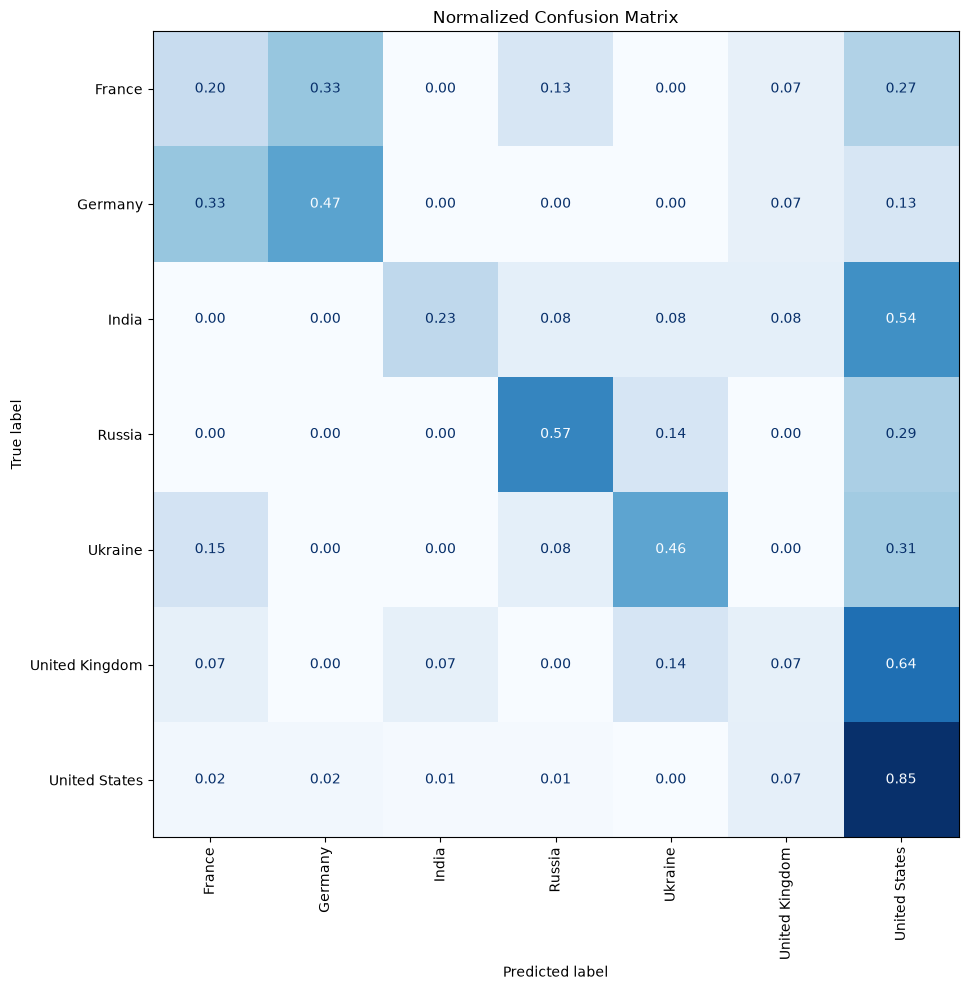

In [32]:
# Confusion matrix
cm = confusion_matrix(
    true_labels_B,
    pred_labels_B,
    labels=le.classes_
)

# Plot
cm_norm = confusion_matrix(
    true_labels_B,
    pred_labels_B,
    labels=le.classes_,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    ax=ax,
    colorbar=False,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

(165, 76, 7)
                                              feature  importance
1                      affected_third_countries_value    0.895574
52                       cyber_conflict_issue_Unknown    0.324197
0                             affected_entities_value    0.302341
58                    functional_impact_Not_available    0.265011
53                 offline_conflict_intensity_Unknown    0.219414
41                          initiator_country_Unknown    0.217699
29                           initiator_country_Russia    0.207948
24                   initiator_country_Not_attributed    0.203375
68                                          topic_1_0    0.200731
54      offline_conflict_intensity_Yes_HIIK_intensity    0.188568
44           cyber_conflict_issue_International_power    0.175799
64                  intelligence_impact_Not_available    0.166846
55                      functional_impact_Days_7_days    0.144816
8                             initiator_country_China    0.1418

/Users/heather.iriye/Library/CloudStorage/OneDrive-KarolinskaInstitutet/Documents/GitHub/eurepoc_cyber_security-/venv/lib/python3.14/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


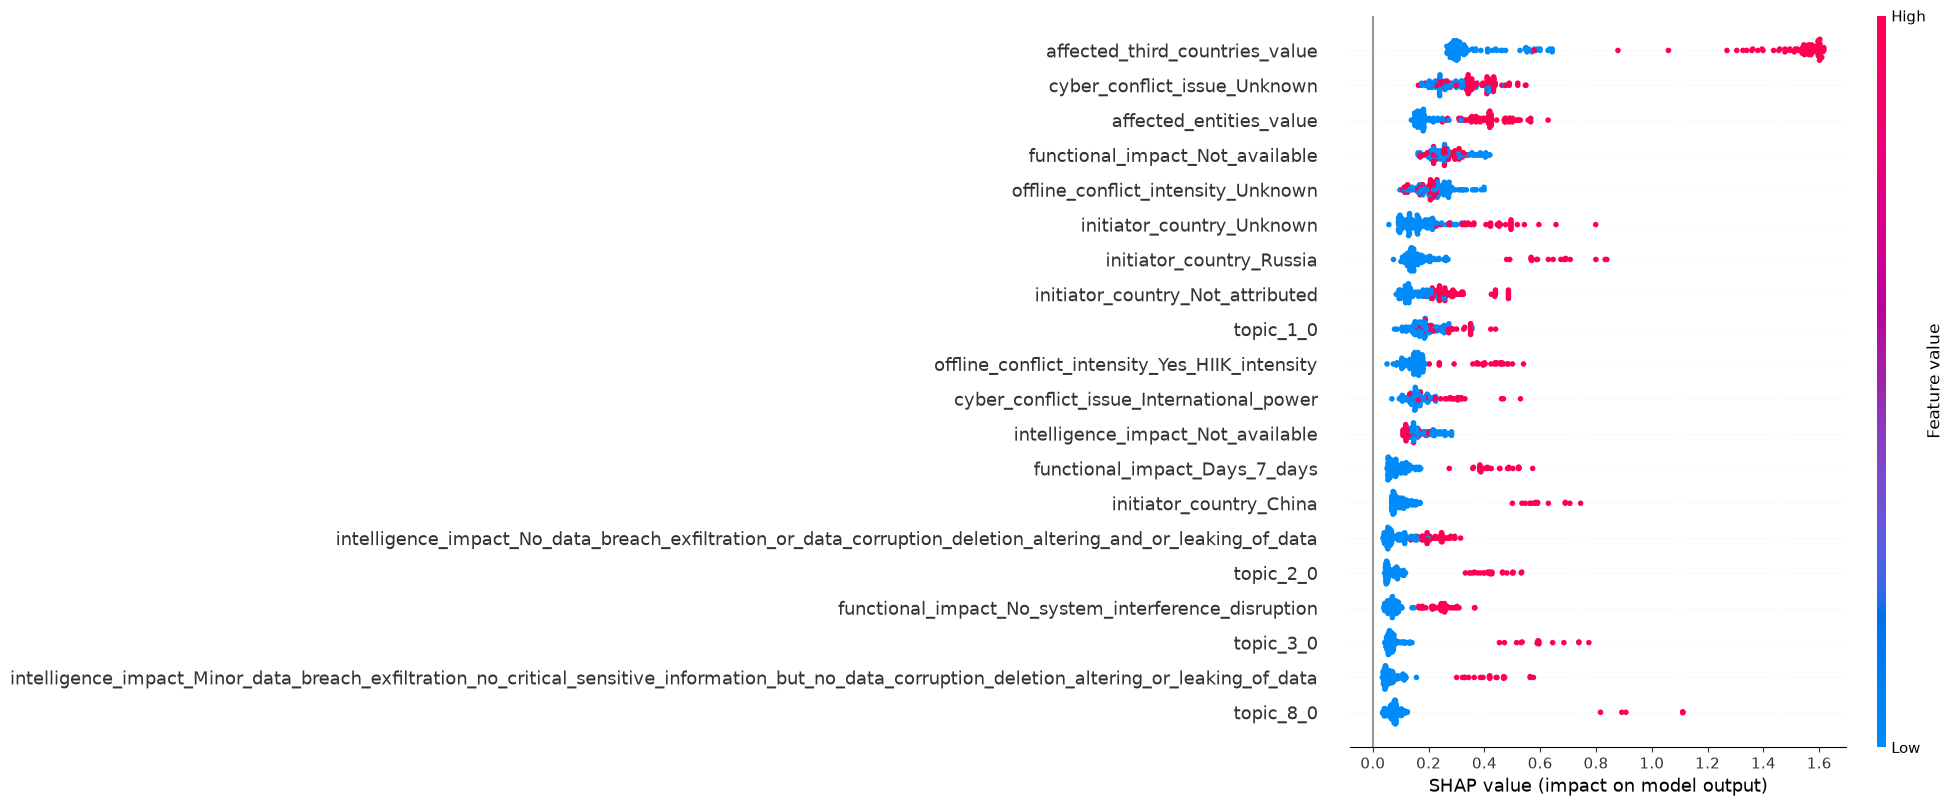

In [33]:
# Assess feature importance
explainer = shap.TreeExplainer(xgbB)
shap_values = explainer.shap_values(X_test_B)
print(shap_values.shape)

mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

shap_importance = pd.DataFrame({
    "feature": X_test_B.columns,
    "importance": mean_abs_shap
}).sort_values(
    "importance",
    ascending=False
)

print(shap_importance.head(20))

shap.summary_plot(
    np.abs(shap_values).mean(axis=2),
    X_test_B
)

## Conclusion

Predictive performance was remarkably similar across manually coded cyber-operation categories and BERTopic-derived latent themes. The traditional taxonomy achieved a balanced accuracy of 0.416 compared to 0.408 for BERTopics. These findings suggest that latent topics successfully recover many of the targeting patterns represented in existing operational classifications, but provide little evidence that they are superior predictors of target selection when used independently.

### Model C: Controls + Existing Categories + BERTopics

In [46]:
existing_lookup = (
    dyadic_data_orig_matched[
        ["incident_id"] + existing_features
    ]
    .drop_duplicates("incident_id")
)

topic_combined = filtered_topic.merge(
    existing_lookup,
    on="incident_id",
    how="left"
)

X_controls = pd.get_dummies(
    topic_combined[control_features],
    drop_first=True
)

X_existing_ops = topic_combined[
    existing_features
]

X_topics = pd.get_dummies(
    topic_combined["topic"],
    prefix="topic",
    drop_first=True
)

X_combined = pd.concat(
    [
        X_controls,
        X_existing_ops,
        X_topics
    ],
    axis=1
)

X_combined.columns = (
    X_combined.columns
    .astype(str)
    .str.replace(r"[^A-Za-z0-9_]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

le = LabelEncoder()

y = le.fit_transform(
    topic_combined["receiver_country"]
)

In [50]:
# Split into training and testing data
X_train_C , X_test_C, y_train_C, y_test_C = train_test_split(
    X_combined,
    y,
    test_size=0.2,
    random_state = 99,
    stratify=y
)

print(X_train_B.shape)
print(X_test_B.shape)
print(y_train_B.shape)
print(y_test_B.shape)

(659, 76)
(165, 76)
(659,)
(165,)


In [51]:
# Define model C
xgbC = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=99
)

# 5-fold stratified CV
cv = StratifiedKFold(
    n_splits = 5,
    shuffle=True,
    random_state=99
)

# Cross-validation on training data
cv_scores_C = cross_val_score(
    xgbC,
    X_train_C,
    y_train_C,
    cv=cv,
    scoring="balanced_accuracy"
)

print("CV Scores:", cv_scores_C)
print("Mean CV Score:", np.mean(cv_scores_C))
print("Std Dev:", np.std(cv_scores_C))

CV Scores: [0.39725275 0.5014319  0.51035631 0.47311022 0.39027639]
Mean CV Score: 0.4544855144855145
Std Dev: 0.051128837512179316


In [52]:
# Fit on the full training set and evaluate on the holdout test set
xgbC.fit(X_train_C, y_train_C)

y_pred_C = xgbC.predict(X_test_C)
pred_labels_C = le.inverse_transform(y_pred_C)
true_labels_C = le.inverse_transform(y_test_C)

print(
    "Test Balanced Accuracy:",
    balanced_accuracy_score(true_labels_C, pred_labels_C)
)

print(classification_report(true_labels_C, pred_labels_C))

Test Balanced Accuracy: 0.4004050623098242
                precision    recall  f1-score   support

        France       0.20      0.20      0.20        15
       Germany       0.45      0.33      0.38        15
         India       0.43      0.23      0.30        13
        Russia       0.42      0.57      0.48        14
       Ukraine       0.57      0.31      0.40        13
United Kingdom       0.33      0.36      0.34        14
 United States       0.71      0.80      0.76        81

      accuracy                           0.56       165
     macro avg       0.45      0.40      0.41       165
  weighted avg       0.55      0.56      0.55       165



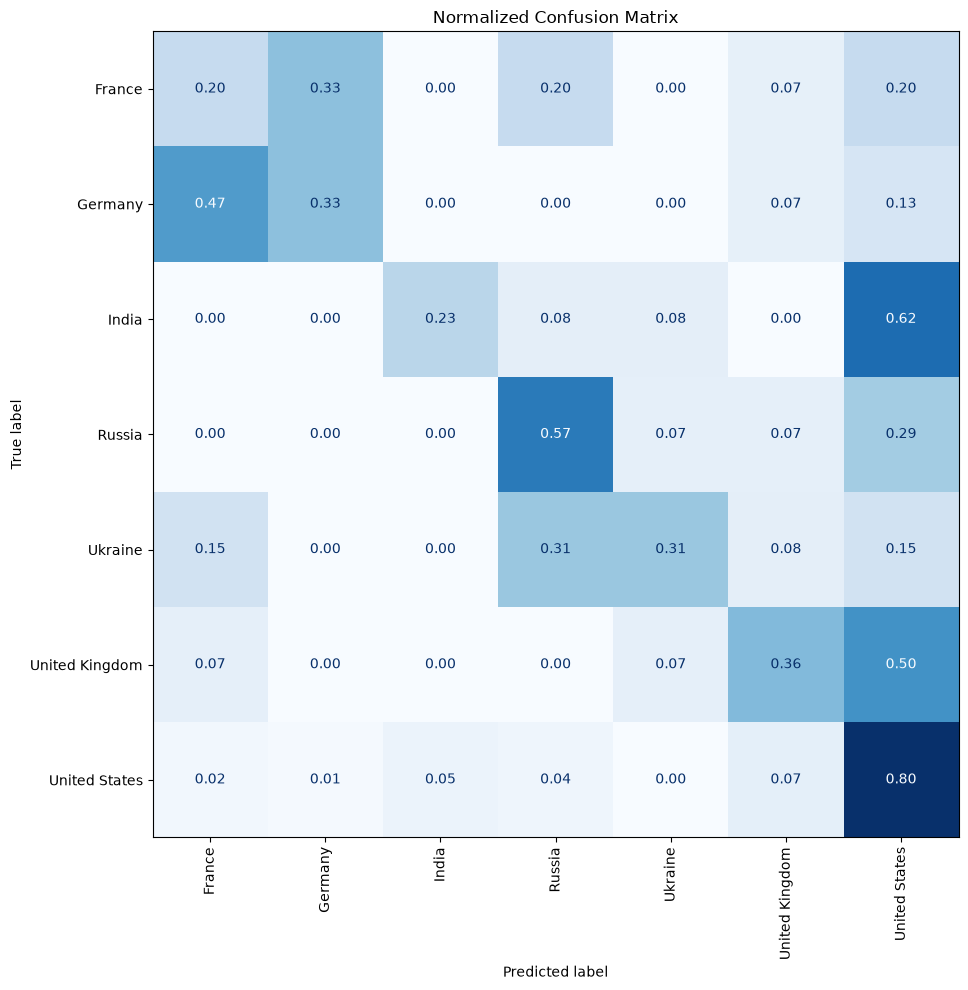

In [53]:
# Confusion matrix
cm = confusion_matrix(
    true_labels_C,
    pred_labels_C,
    labels=le.classes_
)

# Plot
cm_norm = confusion_matrix(
    true_labels_C,
    pred_labels_C,
    labels=le.classes_,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    ax=ax,
    colorbar=False,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

(165, 81, 7)
                                              feature  importance
1                      affected_third_countries_value    0.866886
52                       cyber_conflict_issue_Unknown    0.303944
0                             affected_entities_value    0.297925
58                    functional_impact_Not_available    0.235146
41                          initiator_country_Unknown    0.206813
73                                          topic_1_0    0.195538
24                   initiator_country_Not_attributed    0.192394
29                           initiator_country_Russia    0.189963
54      offline_conflict_intensity_Yes_HIIK_intensity    0.189671
64                  intelligence_impact_Not_available    0.177461
53                 offline_conflict_intensity_Unknown    0.177367
68                                         Data_theft    0.160847
44           cyber_conflict_issue_International_power    0.159146
70                              Hijacking_with_Misuse    0.1568

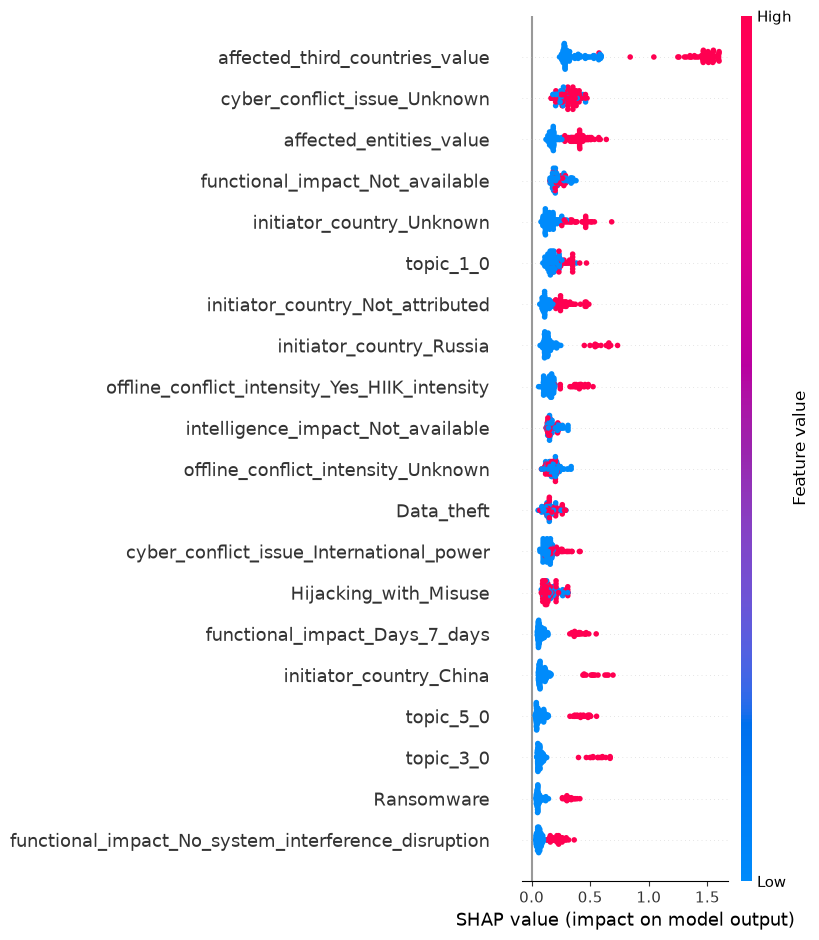

In [54]:
# Assess feature importance
explainer = shap.TreeExplainer(xgbC)
shap_values = explainer.shap_values(X_test_C)
print(shap_values.shape)

mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

shap_importance = pd.DataFrame({
    "feature": X_test_C.columns,
    "importance": mean_abs_shap
}).sort_values(
    "importance",
    ascending=False
)

print(shap_importance.head(20))

shap.summary_plot(
    np.abs(shap_values).mean(axis=2),
    X_test_C
)

BERTopic-derived latent themes achieved predictive performance comparable to the existing cyber-operation taxonomy when anticipating target countries. The existing categories produced a balanced accuracy of 0.416 compared with 0.408 for BERTopics. Combining both representations resulted in a balanced accuracy of 0.400, indicating little additional predictive value from including both simultaneously.

Feature-importance analysis suggests that BERTopics and traditional operation categories capture overlapping dimensions of cyber incidents. While several BERTopic features ranked among the most influential predictors, traditional categories such as Data Theft, Hijacking with Misuse, and Ransomware also remained important. The absence of improvements in the combined model suggests that the latent topics largely recover information already represented in the existing operational taxonomy.